In [1]:
# ACCEPTANCE
import json
import awkward as ak
import numpy as np
from coffea import processor, util, hist
import pickle
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.8/site-packages/coffea/util.py:154: FutureWarning: In coffea version v2023.3.0 (target date: 31 Mar 2023), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [2]:
year = '2018'
templates_reco = pickle.load(open('../'+year+'/stxs-templates.pkl','rb')).sum('msd1')
templates_true = pickle.load(open('../'+year+'/acceptance-truth.pkl','rb')).sum('mode')

In [3]:
acc_unc = {}

In [4]:
def combine(a):
    
    newa = np.array([a.iloc[2] + a.iloc[6], a.iloc[3] + a.iloc[7], a.iloc[4] + a.iloc[8]])
    df = pd.DataFrame(newa, columns=a.columns)
    
    return df.astype('float')

In [5]:
def acceptance_uncertainty(reco,true,syst):
    
    nominal = combine(pd.DataFrame.from_dict(reco.integrate('systematic','nominal').values()))
    reco_up = combine(pd.DataFrame.from_dict(reco.integrate('systematic',syst+'Up').values()))
    reco_do = combine(pd.DataFrame.from_dict(reco.integrate('systematic',syst+'Down').values()))
    
    cats = [c for c in nominal.columns if 'muon' not in c[0]]
    print(cats)
    
    nominal['true'] = combine(pd.DataFrame.from_dict(true.integrate('systematic','nominal').values()[()]))
    reco_up['true'] = combine(pd.DataFrame.from_dict(true.integrate('systematic',syst+'Up').values()[()]))
    reco_do['true'] = combine(pd.DataFrame.from_dict(true.integrate('systematic',syst+'Down').values()[()]))
    
    frac_up = (reco_up/nominal)
    frac_do = (reco_do/nominal)
    
    acc_up = pd.DataFrame()
    acc_do = pd.DataFrame()
    
    for c in cats:
        acc_up[c] = np.divide(frac_up[c],frac_up['true'].to_numpy().flatten())
        acc_do[c] = np.divide(frac_do[c],frac_do['true'].to_numpy().flatten())
        
    acc_up = acc_up.to_dict()
    acc_do = acc_do.to_dict()
    
    acc_unc[syst] = {}
    
    for k,v in acc_up.items():
        acc_unc[syst][k[0]] = {}
        for j,u in v.items():
            acc_unc[syst][k[0]][j] = (acc_up[k][j],acc_do[k][j])


In [6]:
ggf_reco = templates_reco.integrate('process','ggF').integrate('ddb1',int_range=slice(0.64,1)).integrate('genflavor',int_range=slice(1,4))
ggf_reco

<Hist (category,systematic,stxs) instance at 0x7f7cf3553520>

In [7]:
ggf_true = templates_true.integrate('process','ggF')
ggf_true

<Hist (systematic,stxs) instance at 0x7f7cf3553730>

In [8]:
acceptance_uncertainty(ggf_reco,ggf_true,'scalevar_7pt')
acceptance_uncertainty(ggf_reco,ggf_true,'PDFaS_weight')
acceptance_uncertainty(ggf_reco,ggf_true,'UEPS_FSR')
acceptance_uncertainty(ggf_reco,ggf_true,'UEPS_ISR')

acc_unc_pass = acc_unc

[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]
[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]
[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]
[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]


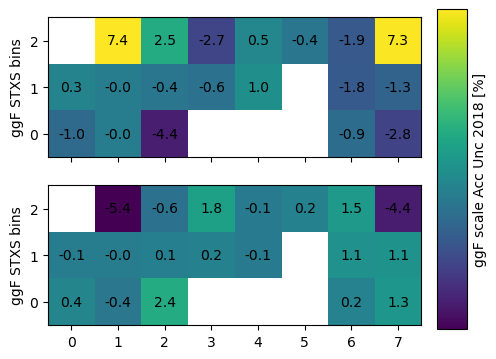

In [9]:
acc_up = pd.DataFrame()
acc_do = pd.DataFrame()
for k,v in acc_unc['scalevar_7pt'].items():
    acc_up[k] = [u[0] for u in v.values()]
    acc_do[k] = [u[1] for u in v.values()]
    

fig, ax = plt.subplots(2,1, figsize=(6,4), sharex=True)

vm = min([acc_up.min().min(),acc_do.min().min()])
vp = max([acc_up.max().max(),acc_do.max().max()])

weights = np.array(acc_up)
im = ax[0].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[0].set_xticks(np.linspace(0,7,8))

ax[0].set_yticks(np.linspace(0,27,28))
ax[0].set_ylim(-0.5,2.5)
ax[0].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[0].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')

weights = np.array(acc_do)
im = ax[1].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[1].set_xticks(np.linspace(0,7,8))

ax[1].set_yticks(np.linspace(0,27,28))
ax[1].set_ylim(-0.5,2.5)
ax[1].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[1].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')

cbar_ax = fig.add_axes([0.85, 0.1, 0.05, 0.8])
fig.colorbar(im, ticks=[], cax=cbar_ax, label='ggF scale Acc Unc '+ year + ' [%]')

plt.savefig(year+'/ggF_acc_scalevar_7pt.png',bbox_inches='tight')
plt.savefig(year+'/ggF_acc_scalevar_7pt.pdf',bbox_inches='tight')

plt.show()

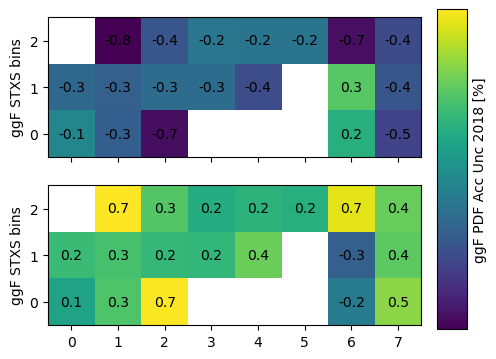

In [10]:
acc_up = pd.DataFrame()
acc_do = pd.DataFrame()
for k,v in acc_unc['PDFaS_weight'].items():
    acc_up[k] = [u[0] for u in v.values()]
    acc_do[k] = [u[1] for u in v.values()]

fig, ax = plt.subplots(2,1, figsize=(6,4), sharex=True)

vm = min([acc_up.min().min(),acc_do.min().min()])
vp = max([acc_up.max().max(),acc_do.max().max()])

weights = np.array(acc_up)
im = ax[0].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[0].set_xticks(np.linspace(0,7,8))

ax[0].set_yticks(np.linspace(0,27,28))
ax[0].set_ylim(-0.5,2.5)
ax[0].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[0].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')

weights = acc_do.to_numpy()
im = ax[1].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[1].set_xticks(np.linspace(0,7,8))

ax[1].set_yticks(np.linspace(0,27,28))
ax[1].set_ylim(-0.5,2.5)
ax[1].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[1].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')
        
cbar_ax = fig.add_axes([0.85, 0.1, 0.05, 0.8])
fig.colorbar(im, ticks=[], cax=cbar_ax, label='ggF PDF Acc Unc '+ year + ' [%]')

plt.savefig(year+'/ggF_acc_PDFaS_weight.png',bbox_inches='tight')
plt.savefig(year+'/ggF_acc_PDFaS_weight.pdf',bbox_inches='tight')

plt.show()

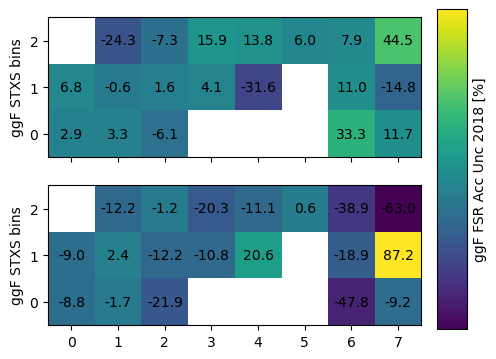

In [11]:
acc_up = pd.DataFrame()
acc_do = pd.DataFrame()
for k,v in acc_unc['UEPS_FSR'].items():
    acc_up[k] = [u[0] for u in v.values()]
    acc_do[k] = [u[1] for u in v.values()]
    
fig, ax = plt.subplots(2,1, figsize=(6,4), sharex=True)

vm = min([acc_up.min().min(),acc_do.min().min()])
vp = max([acc_up.max().max(),acc_do.max().max()])

weights = np.array(acc_up)
im = ax[0].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[0].set_xticks(np.linspace(0,7,8))

ax[0].set_yticks(np.linspace(0,27,28))
ax[0].set_ylim(-0.5,2.5)
ax[0].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[0].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')

weights = np.array(acc_do)
im = ax[1].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[1].set_xticks(np.linspace(0,7,8))

ax[1].set_yticks(np.linspace(0,27,28))
ax[1].set_ylim(-0.5,2.5)
ax[1].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[1].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')
        
cbar_ax = fig.add_axes([0.85, 0.1, 0.05, 0.8])
fig.colorbar(im, ticks=[], cax=cbar_ax, label='ggF FSR Acc Unc '+ year + ' [%]')

plt.savefig(year+'/ggF_acc_UEPS_FSR.png',bbox_inches='tight')
plt.savefig(year+'/ggF_acc_UEPS_FSR.pdf',bbox_inches='tight')

plt.show()

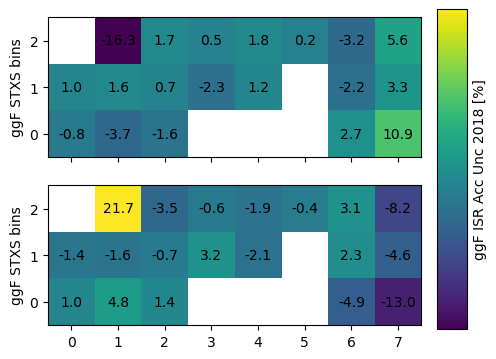

In [12]:
acc_up = pd.DataFrame()
acc_do = pd.DataFrame()
for k,v in acc_unc['UEPS_ISR'].items():
    acc_up[k] = [u[0] for u in v.values()]
    acc_do[k] = [u[1] for u in v.values()]
    
fig, ax = plt.subplots(2,1, figsize=(6,4), sharex=True)

vm = min([acc_up.min().min(),acc_do.min().min()])
vp = max([acc_up.max().max(),acc_do.max().max()])

weights = np.array(acc_up)
im = ax[0].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[0].set_xticks(np.linspace(0,7,8))

ax[0].set_yticks(np.linspace(0,27,28))
ax[0].set_ylim(-0.5,2.5)
ax[0].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[0].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')

weights = np.array(acc_do)
im = ax[1].imshow(weights,origin='lower',vmin=vm,vmax=vp)
ax[1].set_xticks(np.linspace(0,7,8))

ax[1].set_yticks(np.linspace(0,27,28))
ax[1].set_ylim(-0.5,2.5)
ax[1].set_ylabel('ggF STXS bins')

for (j,i),label in np.ndenumerate(weights):
    if label>0:
        ax[1].text(i,j,"{:.1f}".format(100*(label-1)),ha='center',va='center')
        
cbar_ax = fig.add_axes([0.85, 0.1, 0.05, 0.8])
fig.colorbar(im, ticks=[], cax=cbar_ax, label='ggF ISR Acc Unc '+ year + ' [%]')

plt.savefig(year+'/ggF_acc_UEPS_ISR.png',bbox_inches='tight')
plt.savefig(year+'/ggF_acc_UEPS_ISR.pdf',bbox_inches='tight')

plt.show()

In [13]:
acc_unc = {}

ggf_reco_fail = templates_reco.integrate('process','ggF').integrate('ddb1',int_range=slice(0,0.64)).integrate('genflavor',int_range=slice(1,4))
ggf_reco_fail

acceptance_uncertainty(ggf_reco_fail,ggf_true,'scalevar_7pt')
acceptance_uncertainty(ggf_reco_fail,ggf_true,'PDFaS_weight')
acceptance_uncertainty(ggf_reco_fail,ggf_true,'UEPS_FSR')
acceptance_uncertainty(ggf_reco_fail,ggf_true,'UEPS_ISR')

acc_unc_fail = acc_unc


[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]
[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]
[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]
[('ggf-pt1',), ('ggf-pt2',), ('ggf-pt3',), ('ggf-pt4',), ('ggf-pt5',), ('ggf-pt6',), ('vbf-mjj1',), ('vbf-mjj2',)]


In [14]:
acc_unc = {'fail':acc_unc_fail,'pass':acc_unc_pass}

In [15]:
with open(year+"/acc_ggF.json", "w") as outfile:
    json.dump(acc_unc, outfile)